In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, when
from pyspark.sql.functions import explode, avg
from pyspark.sql import functions as F
from pyspark.sql.functions import udf
from pyspark.ml.classification import LogisticRegression
from pyspark.sql.functions import countDistinct
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, VectorSizeHint
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator
from pyspark.ml.stat import Correlation
from pyspark.ml import Pipeline
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.mllib.feature import Normalizer
import re
from tabulate import tabulate
from statsmodels.stats.outliers_influence import variance_inflation_factor


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

In [2]:
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

/opt/conda/lib/python3.7/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/11/28 11:54:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)

In [4]:
seed=42

In [5]:
#path = "/Users/acgid/Downloads/nba_stats/"
#Individual Statistics
file_1 = "Player Award Shares.csv" #Truth data and dependent variable
file_2 = "Player Totals.csv"
file_3 = "Player Per Game.csv"
file_4 = "Player Play By Play.csv"
file_5 = "Player Shooting.csv"
#Advanced Individual Statistics
file_6 = "Advanced.csv"
file_7 = "Per 36 Minutes.csv"
file_8 = "Per 100 Poss.csv"

In [6]:
award_df = spark.read.csv(file_1, header=True, inferSchema=True)
plyr_tot_df = spark.read.csv(file_2, header=True, inferSchema=True)
ppg_df = spark.read.csv(file_3, header=True, inferSchema=True)
plyr_pbp_df = spark.read.csv(file_4, header=True, inferSchema=True)
plyr_shtg_df = spark.read.csv(file_5, header=True, inferSchema=True)
adv_df = spark.read.csv(file_6, header=True, inferSchema=True)
plyr_p36min_df = spark.read.csv(file_7, header=True, inferSchema=True)
plyr_p100ps_df = spark.read.csv(file_8, header=True, inferSchema=True)

In [7]:
# filter for 1980 or higher
award_df_filtered = award_df.filter(award_df.season >= 1980)
print("This is award_df_filtered after filter:",award_df_filtered.count())

plyr_tot_df_filtered = plyr_tot_df.filter(plyr_tot_df.season >= 1980)
print("This is plyr_tot_df_filtered after filter:", plyr_tot_df_filtered.count())

ppg_df_filtered = ppg_df.filter(ppg_df.season >= 1980)
print("This is ppg_df_filtered after filter:", ppg_df_filtered.count())

plyr_pbp_df_filtered = plyr_pbp_df.filter(plyr_pbp_df.season >= 1980)
print("This is plyr_pbp_df_filtered after filter:", plyr_pbp_df_filtered.count())

plyr_shtg_df_filtered = plyr_shtg_df.filter(plyr_shtg_df.season >= 1980)
print("This is plyr_shtg_df_filtered after filter:", plyr_shtg_df_filtered.count())

adv_df_filtered = adv_df.filter(adv_df.season >= 1980)
print("This is adv_df_filtered after filter:", adv_df_filtered.count())

plyr_p36min_df_filtered = plyr_p36min_df.filter(plyr_p36min_df.season >= 1980)
print("This is plyr_p36min_df_filtered after filter:", plyr_p36min_df_filtered.count())

plyr_p100ps_df_filtered = plyr_p100ps_df.filter(plyr_p100ps_df.season >= 1980)
print("This is plyr_p100ps_df_filtered after filter:", plyr_p100ps_df_filtered.count())

This is award_df_filtered after filter: 2897
This is plyr_tot_df_filtered after filter: 24616
This is ppg_df_filtered after filter: 24616
This is plyr_pbp_df_filtered after filter: 17521
This is plyr_shtg_df_filtered after filter: 17521
This is adv_df_filtered after filter: 24616
This is plyr_p36min_df_filtered after filter: 24616
This is plyr_p100ps_df_filtered after filter: 24616


In [8]:
temp1 = plyr_tot_df_filtered.join(ppg_df_filtered, 
                                  on=["season", "lg", "player", "player_id", "age", "team", "pos", "g", "gs","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent","x3p_percent"], 
                                  how="left")
print("this is after merge:",temp1.count())


this is after merge: 24616


In [9]:
temp1.show()

25/11/28 11:54:23 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+---+--------------------+---------+---+----+---+---+---+----------+-----------+------------+----------+-----------+----+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|fg_percent|x2p_percent|e_fg_percent|ft_percent|x3p_percent|  mp| fg| fga|x3p|x3pa|x2p|x2pa| ft|fta|orb|drb|trb|ast|stl|blk|tov| pf| pts|trp_dbl|mp_per_game|fg_per_game|fga_per_game|x3p_per_game|x3pa_per_game|x2p_per_game|x2pa_per_game|ft_per_game|fta_per_game|orb_per_game|drb_per_game|trb_per_game|ast_per_game|stl_per_game|blk_per_game|tov_per_game|pf_per_game|pts_per_game|
+------+---+--------------------+---------+---+----+---+---+---+----------+-----------+------------+----------+-------

In [10]:
temp1.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('fg_percent', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft_percent', 'string'),
 ('x3p_percent', 'string'),
 ('mp', 'string'),
 ('fg', 'int'),
 ('fga', 'int'),
 ('x3p', 'string'),
 ('x3pa', 'string'),
 ('x2p', 'string'),
 ('x2pa', 'string'),
 ('ft', 'int'),
 ('fta', 'int'),
 ('orb', 'string'),
 ('drb', 'string'),
 ('trb', 'string'),
 ('ast', 'int'),
 ('stl', 'string'),
 ('blk', 'string'),
 ('tov', 'string'),
 ('pf', 'string'),
 ('pts', 'int'),
 ('trp_dbl', 'string'),
 ('mp_per_game', 'string'),
 ('fg_per_game', 'double'),
 ('fga_per_game', 'double'),
 ('x3p_per_game', 'string'),
 ('x3pa_per_game', 'string'),
 ('x2p_per_game', 'string'),
 ('x2pa_per_game', 'string'),
 ('ft_per_game', 'double'),
 ('fta_per_game', 'double'),
 ('orb_per_game', 'string'),
 ('drb_per_game', 'string

In [11]:
temp2 = plyr_pbp_df_filtered.join(plyr_shtg_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

print("this is after merge:",temp2.count())



this is after merge: 17521


In [12]:
temp2.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+----------------------------+----------------------------+-------------------------+-----------------------+-----------------------+--------------------+------------+------------------------+----------------------+--------------------+---------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp|pg_percent|sg_percent|sf_percent|pf_percent|c_p

In [13]:
temp2.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'int'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'int'),
 ('mp', 'int'),
 ('pg_percent', 'string'),
 ('sg_percent', 'string'),
 ('sf_percent', 'string'),
 ('pf_percent', 'string'),
 ('c_percent', 'string'),
 ('on_court_plus_minus_per_100_poss', 'string'),
 ('net_plus_minus_per_100_poss', 'string'),
 ('bad_pass_turnover', 'int'),
 ('lost_ball_turnover', 'int'),
 ('shooting_foul_committed', 'int'),
 ('offensive_foul_committed', 'int'),
 ('shooting_foul_drawn', 'int'),
 ('offensive_foul_drawn', 'string'),
 ('points_generated_by_assists', 'int'),
 ('and1', 'int'),
 ('fga_blocked', 'int'),
 ('fg_percent', 'string'),
 ('avg_dist_fga', 'string'),
 ('percent_fga_from_x2p_range', 'string'),
 ('percent_fga_from_x0_3_range', 'string'),
 ('percent_fga_from_x3_10_range', 'string'),
 ('percent_fga_from_x10_16_range', 'string'),
 ('percent_fga_from_x16_3p_range', 'string'),
 ('perce

In [14]:
temp3_a = adv_df_filtered.join(plyr_p36min_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

temp3 = temp3_a.join(plyr_p100ps_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent", "x3p_percent"], 
                                  how="left")


print("this is after merge:",temp3.count())

this is after merge: 24616


In [15]:
temp3.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+----+----------+------+-----+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----+---+----+------+----+----+----+----+-------------+--------------+--------------+---------------+--------------+---------------+-------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+--------------+---------------+----------------+----------------+-----------------+----------------+-----------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+---------------+----------------+-----+-----+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp|fg_percent|x2p_percent|e_fg_percent|ft_percent|x3p_percent| per|ts_percent|x3p_ar|

In [16]:
temp3.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('mp', 'string'),
 ('fg_percent', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft_percent', 'string'),
 ('x3p_percent', 'string'),
 ('per', 'string'),
 ('ts_percent', 'string'),
 ('x3p_ar', 'string'),
 ('f_tr', 'string'),
 ('orb_percent', 'string'),
 ('drb_percent', 'string'),
 ('trb_percent', 'string'),
 ('ast_percent', 'string'),
 ('stl_percent', 'string'),
 ('blk_percent', 'string'),
 ('tov_percent', 'string'),
 ('usg_percent', 'string'),
 ('ows', 'string'),
 ('dws', 'string'),
 ('ws', 'string'),
 ('ws_48', 'string'),
 ('obpm', 'string'),
 ('dbpm', 'string'),
 ('bpm', 'string'),
 ('vorp', 'string'),
 ('fg_per_36_min', 'string'),
 ('fga_per_36_min', 'string'),
 ('x3p_per_36_min', 'string'),
 ('x3pa_per_36_min', 'string'),
 ('x2p_per_36_min', 'string'),
 ('x2pa_per_36_min', 'str

## Merge for Final dataset

Merge Temp1, temp2, & temp3 together. Below is an idea. Not decided how to go about that. 

In [17]:
temp4_a = temp1.join(temp2,
                     on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp","fg_percent"], 
                     how="left")
print("Join temp1 and temp 2:", temp4_a.count())


Join temp1 and temp 2: 24616


In [18]:
temp4 = temp4_a.join(temp3, 
                        on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp","fg_percent", "x2p_percent", "e_fg_percent", "ft_percent", "x3p_percent"], 
                        how="left")
print("Join temp4_a and temp3:", temp4.count())

Join temp4_a and temp3: 24616


In [19]:
award_df_filtered.show()

+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|season|         award|              player|player_id|age|first|pts_won|pts_max|share|winner|
+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|  2024|nba clutch_poy|       Stephen Curry|curryst01| 35|   45|    298|    495|0.602|  true|
|  2024|nba clutch_poy|       DeMar DeRozan|derozde01| 34|   34|    272|    495|0.549| false|
|  2024|nba clutch_poy|Shai Gilgeous-Ale...|gilgesh01| 25|   11|    160|    495|0.323| false|
|  2024|nba clutch_poy|        Nikola Jokić|jokicni01| 28|    4|     85|    495|0.172| false|
|  2024|nba clutch_poy|       Jalen Brunson|brunsja01| 27|    2|     26|    495|0.053| false|
|  2024|nba clutch_poy|         Luka Dončić|doncilu01| 24|    1|     16|    495|0.032| false|
|  2024|nba clutch_poy|        Kyrie Irving|irvinky01| 31|    0|     14|    495|0.028| false|
|  2024|nba clutch_poy|     Anthony Edwards|edwaran01| 22|  

In [20]:
temp4.show()

[Stage 97:>                                                         (0 + 1) / 1]

+------+---+--------------------+---------+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------

In [21]:
temp5 = temp4.join(award_df_filtered,
                   on=["season","player", "player_id", "age"],
                   how="left")

print("Merged with temp 4: ", temp5.count())

Merged with temp 4:  25169


In [22]:
temp5.show()


[Stage 130:>                                                        (0 + 1) / 1]

+------+--------------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------

In [23]:
dup_keys = (
    award_df_filtered
    .groupBy("season", "player", "player_id", "age")
    .agg(F.count("*").alias("cnt"))
    .filter("cnt > 1")
)

print("Duplicate keys in award_df_filtered:", dup_keys.count())
dup_keys.show(10)

Duplicate keys in award_df_filtered: 497
+------+-----------------+---------+---+---+
|season|           player|player_id|age|cnt|
+------+-----------------+---------+---+---+
|  2023|     Nikola Jokić|jokicni01| 27|  2|
|  1996|  Hakeem Olajuwon|olajuha01| 33|  2|
|  2007|   Gerald Wallace|wallage01| 24|  2|
|  2003| Andrei Kirilenko|kirilan01| 21|  2|
|  2019|Spencer Dinwiddie|dinwisp01| 25|  2|
|  2010|      Ben Wallace|wallabe01| 35|  2|
|  2008|       J.R. Smith|smithjr01| 22|  2|
|  2018|   Victor Oladipo|oladivi01| 25|  3|
|  2013|     Jarrett Jack| jackja01| 29|  2|
|  1999|     Vince Carter|cartevi01| 22|  2|
+------+-----------------+---------+---+---+
only showing top 10 rows



In [24]:
dupes_detail = award_df_filtered.join(
    dup_keys,
    on=["season", "player", "player_id", "age"],
    how="inner"
)
dupes_detail.show(20, truncate=False)

+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|season|player                 |player_id|age|award         |first|pts_won|pts_max|share|winner|cnt|
+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|2024  |Shai Gilgeous-Alexander|gilgesh01|25 |nba clutch_poy|11   |160    |495    |0.323|false |4  |
|2024  |Nikola Jokić           |jokicni01|28 |nba clutch_poy|4    |85     |495    |0.172|false |2  |
|2024  |Jalen Brunson          |brunsja01|27 |nba clutch_poy|2    |26     |495    |0.053|false |3  |
|2024  |Luka Dončić            |doncilu01|24 |nba clutch_poy|1    |16     |495    |0.032|false |2  |
|2024  |Anthony Edwards        |edwaran01|22 |nba clutch_poy|1    |6      |495    |0.012|false |2  |
|2024  |Jayson Tatum           |tatumja01|25 |nba clutch_poy|1    |5      |495    |0.01 |false |2  |
|2024  |Giannis Antetokounmpo  |antetgi01|29 |nba clutch_poy|0    |1      |495    |0.002|fa

In [25]:
temp5.groupBy("award","winner").count().show()

+--------------+------+-----+
|         award|winner|count|
+--------------+------+-----+
|       nba mvp| false|  688|
|      nba dpoy|  true|   44|
|          null|  null|22129|
|nba clutch_poy| false|   29|
|       nba roy| false|  218|
|       nba mip|  true|   39|
|      nba smoy|  true|   41|
|       nba mip| false|  825|
|nba clutch_poy|  true|    2|
|      nba smoy| false|  496|
|      nba dpoy| false|  566|
|       nba mvp|  true|   45|
|       nba roy|  true|   47|
+--------------+------+-----+



In [26]:
#temp5.select("award").distinct().show()
#temp5.select("winner").distinct().show()

In [27]:
temp5 = temp5.withColumn(
    "mvp_label",
    F.when(
        (F.col("award") == "nba mvp") & (F.col("winner") == True), 1
    ).otherwise(0)
)


In [28]:
temp5.groupBy("mvp_label").count().show()

+---------+-----+
|mvp_label|count|
+---------+-----+
|        1|   45|
|        0|25124|
+---------+-----+



In [29]:
temp5.show()

[Stage 193:>                                                        (0 + 1) / 1]

+------+--------------------+---------+---+---+----+---+---+---+----+----------+-----------+------------+----------+-----------+---+----+---+----+---+----+---+---+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+------------+-------------+------------+-------------+-----------+------------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+--------

In [30]:
temp5.printSchema()

root
 |-- season: integer (nullable = true)
 |-- player: string (nullable = true)
 |-- player_id: string (nullable = true)
 |-- age: string (nullable = true)
 |-- lg: string (nullable = true)
 |-- team: string (nullable = true)
 |-- pos: string (nullable = true)
 |-- g: integer (nullable = true)
 |-- gs: string (nullable = true)
 |-- mp: string (nullable = true)
 |-- fg_percent: string (nullable = true)
 |-- x2p_percent: string (nullable = true)
 |-- e_fg_percent: string (nullable = true)
 |-- ft_percent: string (nullable = true)
 |-- x3p_percent: string (nullable = true)
 |-- fg: integer (nullable = true)
 |-- fga: integer (nullable = true)
 |-- x3p: string (nullable = true)
 |-- x3pa: string (nullable = true)
 |-- x2p: string (nullable = true)
 |-- x2pa: string (nullable = true)
 |-- ft: integer (nullable = true)
 |-- fta: integer (nullable = true)
 |-- orb: string (nullable = true)
 |-- drb: string (nullable = true)
 |-- trb: string (nullable = true)
 |-- ast: integer (nullable = tr

In [31]:
target_col = "mvp_label"
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint') and c != target_col]
string_cols = [c for c, t in temp5.dtypes if t == 'string']

In [32]:
numeric_cols

['season',
 'g',
 'fg',
 'fga',
 'ft',
 'fta',
 'ast',
 'pts',
 'fg_per_game',
 'fga_per_game',
 'ft_per_game',
 'fta_per_game',
 'ast_per_game',
 'pts_per_game',
 'bad_pass_turnover',
 'lost_ball_turnover',
 'shooting_foul_committed',
 'offensive_foul_committed',
 'shooting_foul_drawn',
 'points_generated_by_assists',
 'and1',
 'fga_blocked',
 'num_of_dunks',
 'num_heaves_attempted',
 'num_heaves_made']

In [33]:
string_cols

['player',
 'player_id',
 'age',
 'lg',
 'team',
 'pos',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p_percent',
 'x3p',
 'x3pa',
 'x2p',
 'x2pa',
 'orb',
 'drb',
 'trb',
 'stl',
 'blk',
 'tov',
 'pf',
 'trp_dbl',
 'mp_per_game',
 'x3p_per_game',
 'x3pa_per_game',
 'x2p_per_game',
 'x2pa_per_game',
 'orb_per_game',
 'drb_per_game',
 'trb_per_game',
 'stl_per_game',
 'blk_per_game',
 'tov_per_game',
 'pf_per_game',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'offensive_foul_drawn',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',
 'percent_fga_from_x3_10_range',
 'percent_fga_from_x10_16_range',
 'percent_fga_from_x16_3p_range',
 'percent_fga_from_x3p_range',
 'fg_percent_from_x2p_range',
 'fg_percent_from_x0_3_range',
 'fg_percent_from_x3_10_range',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x16_3p_range',
 'fg_p

In [34]:
# List of columns you know should be numeric
cols_to_convert = ['age',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p',
 'x3pa',
 'x3p_percent',
 'x2p',
 'x2pa',
 'orb',
 'drb',
 'trb',
 'stl',
 'blk',
 'tov',
 'pf',
 'trp_dbl',
 'mp_per_game',
 'x3p_per_game',
 'x3pa_per_game',
 'x2p_per_game',
 'x2pa_per_game',
 'orb_per_game',
 'drb_per_game',
 'trb_per_game',
 'stl_per_game',
 'blk_per_game',
 'tov_per_game',
 'pf_per_game',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'offensive_foul_drawn',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',
 'percent_fga_from_x3_10_range',
 'percent_fga_from_x10_16_range',
 'percent_fga_from_x16_3p_range',
 'percent_fga_from_x3p_range',
 'fg_percent_from_x2p_range',
 'fg_percent_from_x0_3_range',
 'fg_percent_from_x3_10_range',
 'fg_percent_from_x10_16_range',
 'fg_percent_from_x16_3p_range',
 'fg_percent_from_x3p_range',
 'percent_assisted_x2p_fg',
 'percent_assisted_x3p_fg',
 'percent_dunks_of_fga',
 'percent_corner_3s_of_3pa',
 'corner_3_point_percent',
 'per',
 'ts_percent',
 'x3p_ar',
 'f_tr',
 'orb_percent',
 'drb_percent',
 'trb_percent',
 'ast_percent',
 'stl_percent',
 'blk_percent',
 'tov_percent',
 'usg_percent',
 'ows',
 'dws',
 'ws',
 'ws_48',
 'obpm',
 'dbpm',
 'bpm',
 'vorp',
 'fg_per_36_min',
 'fga_per_36_min',
 'x3p_per_36_min',
 'x3pa_per_36_min',
 'x2p_per_36_min',
 'x2pa_per_36_min',
 'ft_per_36_min',
 'fta_per_36_min',
 'orb_per_36_min',
 'drb_per_36_min',
 'trb_per_36_min',
 'ast_per_36_min',
 'stl_per_36_min',
 'blk_per_36_min',
 'tov_per_36_min',
 'pf_per_36_min',
 'pts_per_36_min',
 'fg_per_100_poss',
 'fga_per_100_poss',
 'x3p_per_100_poss',
 'x3pa_per_100_poss',
 'x2p_per_100_poss',
 'x2pa_per_100_poss',
 'ft_per_100_poss',
 'fta_per_100_poss',
 'orb_per_100_poss',
 'drb_per_100_poss',
 'trb_per_100_poss',
 'ast_per_100_poss',
 'stl_per_100_poss',
 'blk_per_100_poss',
 'tov_per_100_poss',
 'pf_per_100_poss',
 'pts_per_100_poss',
 'o_rtg',
 'd_rtg',
 'first',
 'pts_won',
 'pts_max',
 'share']


In [35]:

for c in cols_to_convert:
    temp5 = temp5.withColumn(c, F.col(c).cast("double"))


numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()
print(corr_matrix)

In [36]:

# Compute correlation matrix
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()

# Display as a clean formatted table
print(tabulate(corr_matrix, headers='keys', tablefmt='psql', floatfmt=".3f"))

+----------------------------------+----------+--------+--------+--------+--------+--------------+---------------+----------------+--------------+---------------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+--------+-----------+---------------+---------------+----------------+----------------+-----------------+----------------+-----------------+---------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+---------------+----------------+--------------+--------------+--------------+--------------+-------------+------------------------------------+-------------------------------+---------------------+----------------------+---------------------------+----------------------------+-----------------------+------------------------+-------------------------------+--------+---------------+----------------+-

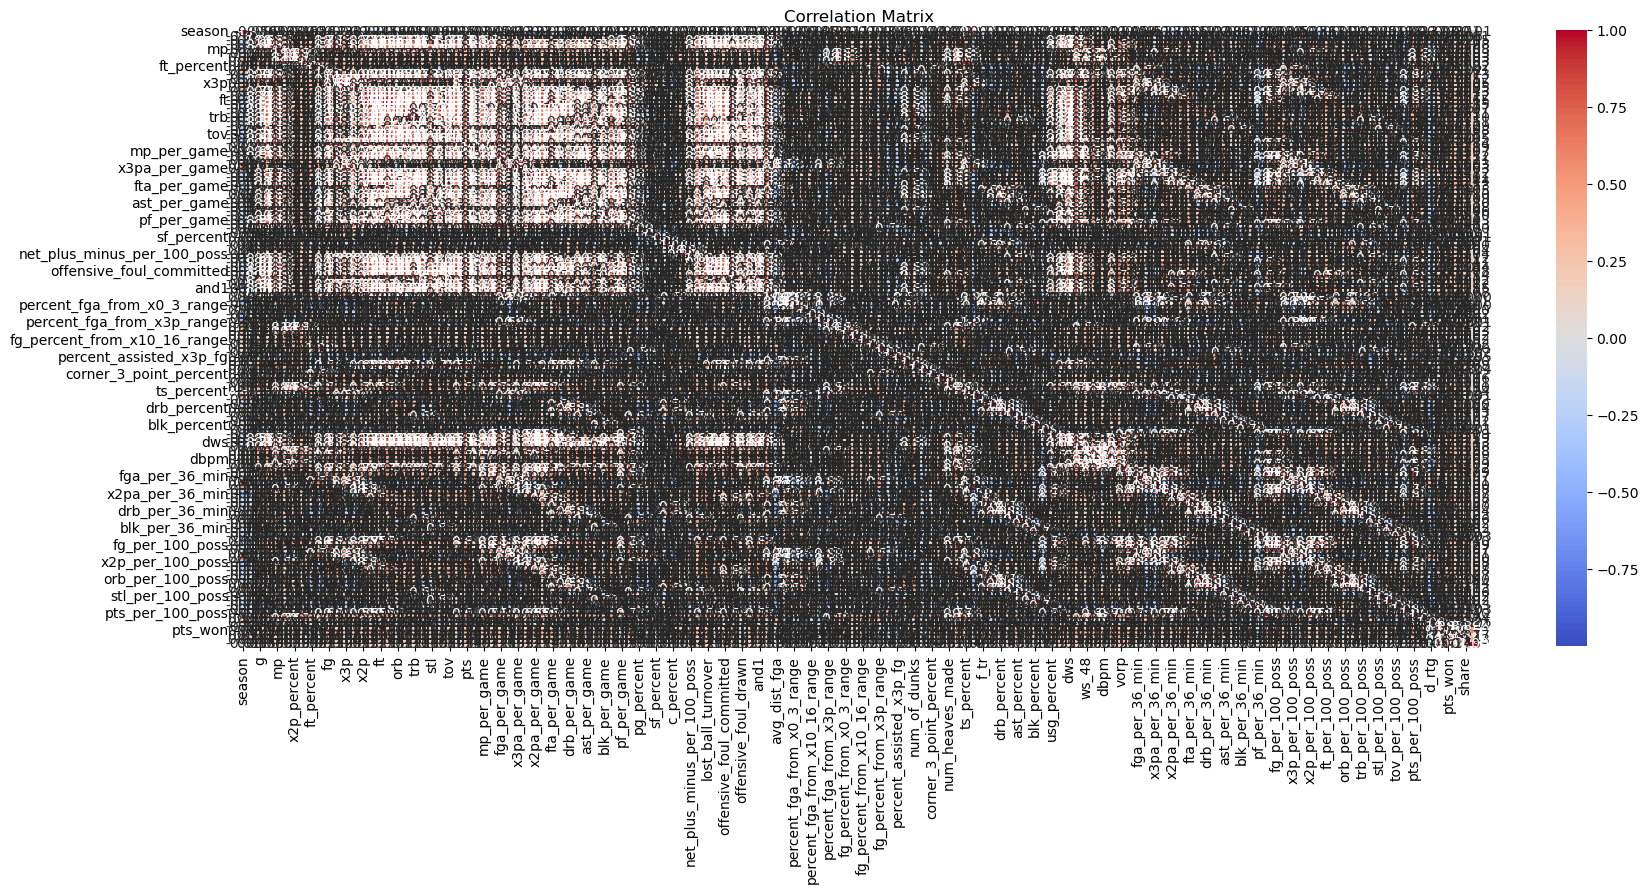

In [37]:
plt.figure(figsize=(20,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Variable Selection

In [38]:
# ---- CONFIG ----
label_col = "mvp_label"       # label column
problem_type = "regression"   # or "classification"
seed = 314
corr_threshold = 0.9

In [39]:
# STEP 1: Select numeric columns only
# ============================================================
numeric_cols = [f.name for f in temp5.schema.fields if f.dataType.simpleString() in ('int', 'double', 'float')]
categorical_cols = [f.name for f in temp5.schema.fields if f.dataType.simpleString() == 'string']

In [40]:
numeric_cols

['season',
 'age',
 'g',
 'gs',
 'mp',
 'fg_percent',
 'x2p_percent',
 'e_fg_percent',
 'ft_percent',
 'x3p_percent',
 'fg',
 'fga',
 'x3p',
 'x3pa',
 'x2p',
 'x2pa',
 'ft',
 'fta',
 'orb',
 'drb',
 'trb',
 'ast',
 'stl',
 'blk',
 'tov',
 'pf',
 'pts',
 'trp_dbl',
 'mp_per_game',
 'fg_per_game',
 'fga_per_game',
 'x3p_per_game',
 'x3pa_per_game',
 'x2p_per_game',
 'x2pa_per_game',
 'ft_per_game',
 'fta_per_game',
 'orb_per_game',
 'drb_per_game',
 'trb_per_game',
 'ast_per_game',
 'stl_per_game',
 'blk_per_game',
 'tov_per_game',
 'pf_per_game',
 'pts_per_game',
 'pg_percent',
 'sg_percent',
 'sf_percent',
 'pf_percent',
 'c_percent',
 'on_court_plus_minus_per_100_poss',
 'net_plus_minus_per_100_poss',
 'bad_pass_turnover',
 'lost_ball_turnover',
 'shooting_foul_committed',
 'offensive_foul_committed',
 'shooting_foul_drawn',
 'offensive_foul_drawn',
 'points_generated_by_assists',
 'and1',
 'fga_blocked',
 'avg_dist_fga',
 'percent_fga_from_x2p_range',
 'percent_fga_from_x0_3_range',


In [41]:
categorical_cols

['player', 'player_id', 'lg', 'team', 'pos', 'award']

In [42]:
# 3a. Ensure all numeric columns are double type
for c in numeric_cols:
    temp5 = temp5.withColumn(c, col(c).cast(DoubleType()))

# 3b. Replace null/NaN values with 0.0 (you can use mean instead if needed)
for c in numeric_cols:
    temp5 = temp5.withColumn(c, when(col(c).isNotNull(), col(c)).otherwise(0.0))

# 3c. Filter out weird/struct names (rare Spark issue)
numeric_cols = [c for c in numeric_cols if "." not in c and not c.endswith("_VectorAssembler")]
print(f"Cleaned numeric columns ready: {len(numeric_cols)}")

Cleaned numeric columns ready: 144


In [43]:
# 4. Correlation analysis for multicollinearity
# ======================================================
assembler_corr = VectorAssembler(inputCols=numeric_cols, outputCol="features_corr")
corr_data = assembler_corr.transform(temp5).select("features_corr")

# Compute correlation matrix
corr_matrix = Correlation.corr(corr_data, "features_corr", "pearson").head()[0].toArray()

# Convert to DataFrame for easy inspection
corr_df = pd.DataFrame(corr_matrix, columns=numeric_cols, index=numeric_cols)

# Flatten matrix into long form (feature1, feature2, corr_value)
corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_matrix[i, j]))

# Convert to pandas DataFrame for sorting
corr_pairs_df = pd.DataFrame(corr_pairs, columns=["Feature1", "Feature2", "Correlation"])

# Add absolute correlation column for ranking
corr_pairs_df["AbsCorrelation"] = corr_pairs_df["Correlation"].abs()

# Sort descending by absolute correlation
corr_pairs_df = corr_pairs_df.sort_values(by="AbsCorrelation", ascending=False)

# Optional threshold filter
corr_threshold = 0.7
high_corr_df = corr_pairs_df[corr_pairs_df["AbsCorrelation"] > corr_threshold]

print("Top Correlations (Ranked by |r|):")
print(high_corr_df.to_string(index=False))

Top Correlations (Ranked by |r|):
                        Feature1                     Feature2  Correlation  AbsCorrelation
                     stl_percent             stl_per_100_poss     0.999986        0.999986
                 x3pa_per_36_min            x3pa_per_100_poss     0.998233        0.998233
                  x3p_per_36_min             x3p_per_100_poss     0.998117        0.998117
                  blk_per_36_min             blk_per_100_poss     0.997246        0.997246
                     trb_percent             trb_per_100_poss     0.997232        0.997232
                  orb_per_36_min             orb_per_100_poss     0.996830        0.996830
                     orb_percent             orb_per_100_poss     0.996469        0.996469
                  fta_per_36_min             fta_per_100_poss     0.996450        0.996450
                  ast_per_36_min             ast_per_100_poss     0.996326        0.996326
                   ft_per_36_min              ft_per_100

In [44]:
#high_corr_df.to_csv("ranked_correlations.csv", index=False)

In [45]:
# VIF Analysis (pure Spark)
# ======================================================

vif_list = []

for target_col in numeric_cols:
    # Use all other columns as predictors
    input_features = [c for c in numeric_cols if c != target_col]

    # Assemble predictors
    assembler = VectorAssembler(inputCols=input_features, outputCol="features_vif")
    df_vif = assembler.transform(temp5).select(col(target_col).alias("label"), "features_vif")

    # Fit linear regression
    lr = LinearRegression(featuresCol="features_vif", labelCol="label")
    lr_model = lr.fit(df_vif)

    # Compute R² and VIF
    r2 = lr_model.summary.r2
    vif = float("inf") if r2 >= 1 else 1 / (1 - r2)
    vif_list.append((target_col, r2, vif))

# Convert to DataFrame for inspection
vif_df = spark.createDataFrame(vif_list, ["Feature", "R2", "VIF"]).orderBy(col("VIF").desc())
vif_df.show(truncate=False)

[Stage 267:>                                                        (0 + 1) / 1]

25/11/28 11:58:06 WARN Instrumentation: [c6f170b9] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 11:58:09 WARN Instrumentation: [c6f170b9] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


[Stage 307:>                                                        (0 + 1) / 1]

25/11/28 11:58:28 WARN Instrumentation: [369d1268] regParam is zero, which might cause numerical instability and overfitting.


...

25/11/28 12:42:44 WARN Instrumentation: [836cc19a] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


[Stage 6416:>                                                       (0 + 1) / 1]

25/11/28 12:43:00 WARN Instrumentation: [c2b77a0e] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:43:02 WARN Instrumentation: [c2b77a0e] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


+--------------------------+------------------+------------------+
|Feature                   |R2                |VIF               |
+--------------------------+------------------+------------------+
|trb                       |0.9999824912368845|57114.25720969767 |
|percent_fga_from_x2p_range|0.9999412531420379|17022.186967759004|
|pts                       |0.9999167512876206|12012.197803641822|
|bpm                       |0.9999011922718622|10120.66585121631 |
|drb                       |0.9998670868441036|7523.709697930352 |
|stl_per_100_poss          |0.9998601724384429|7151.665872338957 |
|stl_percent               |0.99985825058992  |7054.703080847195 |
|fg                        |0.9998472251079804|6545.5781822562985|
|obpm                      |0.9998296365168967|5869.802505703231 |
|pts_per_game              |0.9998227522522215|5641.82062978695  |
|pts_per_100_poss          |0.9998173119646597|5473.812218394112 |
|pts_per_36_min            |0.9997822623784165|4592.6835827794

In [46]:
vif_threshold = 10.0
selected_vif_df = vif_df.filter(col("VIF") <= vif_threshold)

In [47]:
selected_vif_df.show()

+--------------------+------------------+------------------+
|             Feature|                R2|               VIF|
+--------------------+------------------+------------------+
|         fga_blocked|0.8911051095025174| 9.183167322466042|
|shooting_foul_com...|0.8868783104304186| 8.840037695732066|
|               o_rtg|0.8843347848256512| 8.645641634718292|
|fg_percent_from_x...|0.8810809239462123| 8.409079797657483|
|             pts_won|0.8772022260317995| 8.143470094653008|
|               first|0.8697055387922348| 7.674923329284257|
|percent_assisted_...| 0.846247143635147| 6.503944210486837|
|         tov_percent|0.8414592341346665|  6.30752598261959|
|               d_rtg| 0.838959162280627| 6.209605055225697|
|percent_assisted_...|0.8156380628587488| 5.424113108736961|
|        num_of_dunks|0.8151097482507159| 5.408613977961508|
|offensive_foul_co...|0.8116925913437296| 5.310465515594048|
|         x3p_percent|0.8113826890041432| 5.301740305384623|
|                  gs|0.

In [48]:
selected_vif_df.count()

29

In [49]:
[row["Feature"] for row in selected_vif_df.collect()]

['fga_blocked',
 'shooting_foul_committed',
 'o_rtg',
 'fg_percent_from_x0_3_range',
 'pts_won',
 'first',
 'percent_assisted_x3p_fg',
 'tov_percent',
 'd_rtg',
 'percent_assisted_x2p_fg',
 'num_of_dunks',
 'offensive_foul_committed',
 'x3p_percent',
 'gs',
 'f_tr',
 'percent_dunks_of_fga',
 'fg_percent_from_x3_10_range',
 'corner_3_point_percent',
 'ft_percent',
 'fg_percent_from_x16_3p_range',
 'fg_percent_from_x10_16_range',
 'mvp_label',
 'pts_max',
 'percent_corner_3s_of_3pa',
 'offensive_foul_drawn',
 'num_heaves_attempted',
 'trp_dbl',
 'age',
 'num_heaves_made']

In [50]:
selected_features=[row["Feature"] for row in selected_vif_df.collect()]

In [51]:
# 5. Backward Elimination (using VIF-selected variables)
# ======================================================
def backward_elimination(df, features, label_col):
    remaining = features.copy()
    best_model = None
    last_rmse = float("inf")

    while len(remaining) > 1:
        rmse_results = []
        for feat in remaining:
            subset = [f for f in remaining if f != feat]
            assembler = VectorAssembler(inputCols=subset, outputCol="features")
            df_subset = assembler.transform(df).select("features", label_col)
            model = LinearRegression(featuresCol="features", labelCol=label_col)
            lr_model = model.fit(df_subset)
            rmse = lr_model.summary.rootMeanSquaredError
            rmse_results.append((feat, rmse))
        
        # find worst variable (whose removal improves RMSE)
        worst_feat, worst_rmse = max(rmse_results, key=lambda x: x[1])

        if worst_rmse < last_rmse:
            last_rmse = worst_rmse
            remaining.remove(worst_feat)
            best_model = (remaining.copy(), last_rmse)
        else:
            break
    return best_model



In [52]:
# Run backward elimination on the selected features
label_col = "mvp_label"  # label column
best_features, best_rmse = backward_elimination(temp5, selected_features, label_col)

print("\n=== Final Selected Features (after Backward Elimination) ===")
for f in best_features:
    print(f)

print(f"\nFinal RMSE: {best_rmse:.4f}")

25/11/28 12:43:20 WARN Instrumentation: [d604ffa3] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:43:36 WARN Instrumentation: [57afc3cd] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:43:54 WARN Instrumentation: [f455f20e] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:44:13 WARN Instrumentation: [aa3849c2] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:44:31 WARN Instrumentation: [cb880469] regParam is zero, which might cause numerical instability and overfitting.


...

25/11/28 12:58:14 WARN Instrumentation: [b04f6b8f] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:58:29 WARN Instrumentation: [3e641118] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:58:45 WARN Instrumentation: [58191939] regParam is zero, which might cause numerical instability and overfitting.


[Stage 8728:>                                                       (0 + 1) / 1]


=== Final Selected Features (after Backward Elimination) ===
fga_blocked
shooting_foul_committed
o_rtg
fg_percent_from_x0_3_range
pts_won
first
percent_assisted_x3p_fg
tov_percent
d_rtg
percent_assisted_x2p_fg
num_of_dunks
offensive_foul_committed
x3p_percent
gs
f_tr
percent_dunks_of_fga
fg_percent_from_x3_10_range
corner_3_point_percent
ft_percent
fg_percent_from_x16_3p_range
fg_percent_from_x10_16_range
pts_max
percent_corner_3s_of_3pa
offensive_foul_drawn
num_heaves_attempted
trp_dbl
age
num_heaves_made

Final RMSE: 0.0332


In [53]:
best_features

['fga_blocked',
 'shooting_foul_committed',
 'o_rtg',
 'fg_percent_from_x0_3_range',
 'pts_won',
 'first',
 'percent_assisted_x3p_fg',
 'tov_percent',
 'd_rtg',
 'percent_assisted_x2p_fg',
 'num_of_dunks',
 'offensive_foul_committed',
 'x3p_percent',
 'gs',
 'f_tr',
 'percent_dunks_of_fga',
 'fg_percent_from_x3_10_range',
 'corner_3_point_percent',
 'ft_percent',
 'fg_percent_from_x16_3p_range',
 'fg_percent_from_x10_16_range',
 'pts_max',
 'percent_corner_3s_of_3pa',
 'offensive_foul_drawn',
 'num_heaves_attempted',
 'trp_dbl',
 'age',
 'num_heaves_made']

In [54]:
# 7. Forward Selection
# ======================================================
def forward_selection(df, features, label_col):
    selected = []
    remaining = features.copy()
    best_model = None
    last_rmse = float("inf")

    while remaining:
        rmse_results = []
        for feat in remaining:
            subset = selected + [feat]
            assembler = VectorAssembler(inputCols=subset, outputCol="features")
            df_subset = assembler.transform(df).select("features", label_col)
            model = LinearRegression(featuresCol="features", labelCol=label_col)
            lr_model = model.fit(df_subset)
            rmse = lr_model.summary.rootMeanSquaredError
            rmse_results.append((feat, rmse))
        
        best_feat, best_rmse = min(rmse_results, key=lambda x: x[1])
        if best_rmse < last_rmse:
            last_rmse = best_rmse
            selected.append(best_feat)
            remaining.remove(best_feat)
            best_model = (selected.copy(), last_rmse)
        else:
            break
    return best_model



In [55]:
# ======================================================
# Run Forward Selection using the backward-selected variables
# Make sure `best_features` and `label_col` are defined from previous step
best_forward_features, best_forward_rmse = forward_selection(temp5, best_features, label_col)


25/11/28 12:59:01 WARN Instrumentation: [9d8120da] regParam is zero, which might cause numerical instability and overfitting.
25/11/28 12:59:10 WARN Instrumentation: [d1022441] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:59:20 WARN Instrumentation: [4f3aee3a] regParam is zero, which might cause numerical instability and overfitting.
25/11/28 12:59:29 WARN Instrumentation: [3aaf83f3] regParam is zero, which might cause numerical instability and overfitting.
25/11/28 12:59:38 WARN Instrumentation: [73294612] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:59:47 WARN Instrumentation: [9f877ae3] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 12:59:56 WARN Instrumentation: [f3147f43] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 13:00:06 WARN Instrumentation: [02587e14] regParam is zero, which might cause numerical instability and overfitting.


...

25/11/28 14:06:58 WARN Instrumentation: [b52941cf] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 14:07:14 WARN Instrumentation: [f0371dd5] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 14:07:30 WARN Instrumentation: [4e0d7119] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 14:07:47 WARN Instrumentation: [80e01803] regParam is zero, which might cause numerical instability and overfitting.


25/11/28 14:08:04 WARN Instrumentation: [bdb6e82e] regParam is zero, which might cause numerical instability and overfitting.


In [56]:
best_forward_features

['pts_won',
 'pts_max',
 'num_of_dunks',
 'trp_dbl',
 'first',
 'offensive_foul_committed',
 'percent_assisted_x2p_fg',
 'offensive_foul_drawn',
 'shooting_foul_committed',
 'age',
 'fga_blocked',
 'gs',
 'percent_dunks_of_fga',
 'num_heaves_attempted',
 'ft_percent',
 'fg_percent_from_x0_3_range',
 'f_tr',
 'num_heaves_made',
 'fg_percent_from_x3_10_range',
 'o_rtg',
 'x3p_percent',
 'percent_assisted_x3p_fg',
 'd_rtg',
 'corner_3_point_percent',
 'fg_percent_from_x10_16_range',
 'percent_corner_3s_of_3pa',
 'tov_percent',
 'fg_percent_from_x16_3p_range']

In [57]:
final_features = best_forward_features  # from previous step
label_col = "mvp_label"
# Assemble feature vector
assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_model = assembler.transform(temp5).select("features", label_col)

# Optional: Split data for training/testing
train_df, test_df = df_model.randomSplit([0.7, 0.3], seed=seed)

In [58]:
# Logistic Regression
log_reg = LogisticRegression(featuresCol="features", labelCol=label_col)
log_model = log_reg.fit(train_df)
log_predictions = log_model.transform(test_df)

# Evaluate
evaluator = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction")
log_auc = evaluator.evaluate(log_predictions)
print(f"\nLogistic Regression AUC: {log_auc:.4f}")


Logistic Regression AUC: 0.9997


In [59]:
# Random Forest

rf = RandomForestClassifier(featuresCol="features", labelCol=label_col, numTrees=100, seed=42)
rf_model = rf.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_auc = evaluator.evaluate(rf_predictions)
print(f"Random Forest AUC: {rf_auc:.4f}")

[Stage 25263:>                                                      (0 + 1) / 1]

Random Forest AUC: 0.9998


In [60]:
# Feature Importance (Random Forest)
feature_importances = list(zip(final_features, rf_model.featureImportances.toArray()))
feature_importances_sorted = sorted(feature_importances, key=lambda x: x[1], reverse=True)

print("\nTop Feature Importances (Random Forest):")
for feat, imp in feature_importances_sorted[:10]:
    print(f"{feat}: {imp:.4f}")


Top Feature Importances (Random Forest):
first: 0.2786
pts_max: 0.2167
trp_dbl: 0.0745
pts_won: 0.0462
o_rtg: 0.0332
gs: 0.0313
age: 0.0303
fg_percent_from_x3_10_range: 0.0272
d_rtg: 0.0259
percent_corner_3s_of_3pa: 0.0229


In [71]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType
import pyspark.sql.functions as F
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Safe function to extract prob1 no matter what Spark returns
def extract_prob1(prob):
    try:
        # If it's a dense/sparse vector:
        return float(prob[1])
    except:
        try:
            # If it's a list:
            return float(prob[1])
        except:
            try:
                # If it's a dict (Spark weirdness):
                return float(prob.get(1)) or float(prob.get("1"))
            except:
                return 0.0

extract_prob1_udf = udf(extract_prob1, DoubleType())


def compute_metrics(pred_df, label_col):

    # Ensure predicted probability column exists and extract prob of class 1
    pred_df2 = pred_df.withColumn("prob1", extract_prob1_udf(col("probability")))

    # Classification evaluators
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="accuracy"
    )
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="f1"
    )
    evaluator_prec = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="precisionByLabel"
    )
    evaluator_rec = MulticlassClassificationEvaluator(
        labelCol=label_col, predictionCol="prediction", metricName="recallByLabel"
    )
    evaluator_auc = BinaryClassificationEvaluator(
        labelCol=label_col, rawPredictionCol="rawPrediction"
    )

    accuracy = evaluator_acc.evaluate(pred_df2)
    f1 = evaluator_f1.evaluate(pred_df2)
    precision = evaluator_prec.evaluate(pred_df2)
    recall = evaluator_rec.evaluate(pred_df2)
    auc = evaluator_auc.evaluate(pred_df2)

    # RMSE
    rmse = pred_df2.select(
        F.sqrt(F.mean((col("prob1") - col(label_col)) ** 2))
    ).first()[0]

    # R2
    mean_label = pred_df2.select(F.mean(col(label_col))).first()[0]
    ss_tot = pred_df2.select(
        F.sum((col(label_col) - mean_label) ** 2)
    ).first()[0]
    ss_res = pred_df2.select(
        F.sum((col(label_col) - col("prob1")) ** 2)
    ).first()[0]
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else None

    # Confusion matrix
    cm = pred_df2.groupBy(label_col, "prediction").count().orderBy(label_col, "prediction")

    return accuracy, precision, recall, f1, auc, rmse, r2, cm


In [72]:
# Logistic Regression
log_reg = LogisticRegression(
    featuresCol="features",
    labelCol=label_col,
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    predictionCol="prediction"
)

log_model = log_reg.fit(train_df)

log_train_pred = log_model.transform(train_df)
log_test_pred  = log_model.transform(test_df)

log_train_metrics = compute_metrics(log_train_pred, label_col)
log_test_metrics  = compute_metrics(log_test_pred, label_col)



In [66]:
log_predictions

DataFrame[features: vector, mvp_label: double, rawPrediction: vector, probability: vector, prediction: double]

In [73]:

print("\n==================== LOGISTIC REGRESSION ====================")
print("TRAIN")
print(f"Accuracy:  {log_train_metrics[0]:.4f}")
print(f"Precision: {log_train_metrics[1]:.4f}")
print(f"Recall:    {log_train_metrics[2]:.4f}")
print(f"F1 Score:  {log_train_metrics[3]:.4f}")
print(f"AUC:       {log_train_metrics[4]:.4f}")
print(f"RMSE:      {log_train_metrics[5]:.4f}")
print(f"R2:        {log_train_metrics[6]:.4f}")
log_train_metrics[7].show()

print("\nTEST")
print(f"Accuracy:  {log_test_metrics[0]:.4f}")
print(f"Precision: {log_test_metrics[1]:.4f}")
print(f"Recall:    {log_test_metrics[2]:.4f}")
print(f"F1 Score:  {log_test_metrics[3]:.4f}")
print(f"AUC:       {log_test_metrics[4]:.4f}")
print(f"RMSE:      {log_test_metrics[5]:.4f}")
print(f"R2:        {log_test_metrics[6]:.4f}")
log_test_metrics[7].show()


==================== LOGISTIC REGRESSION ====================
TRAIN
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC:       1.0000
RMSE:      0.0000
R2:        1.0000


+---------+----------+-----+
|mvp_label|prediction|count|
+---------+----------+-----+
|      0.0|       0.0|17491|
|      1.0|       1.0|   30|
+---------+----------+-----+


TEST
Accuracy:  0.9991
Precision: 0.9999
Recall:    0.9992
F1 Score:  0.9991
AUC:       0.9997
RMSE:      0.0303
R2:        0.5324


[Stage 26370:>                                                      (0 + 1) / 1]

+---------+----------+-----+
|mvp_label|prediction|count|
+---------+----------+-----+
|      0.0|       0.0| 7627|
|      0.0|       1.0|    6|
|      1.0|       0.0|    1|
|      1.0|       1.0|   14|
+---------+----------+-----+



In [74]:
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=label_col,
    numTrees=100,
    seed=seed
)

rf_model = rf.fit(train_df)

rf_train_pred = rf_model.transform(train_df)
rf_test_pred  = rf_model.transform(test_df)

rf_train_metrics = compute_metrics(rf_train_pred, label_col)
rf_test_metrics  = compute_metrics(rf_test_pred, label_col)



In [75]:

print("\n==================== RANDOM FOREST ====================")
print("TRAIN")
print(f"Accuracy:  {rf_train_metrics[0]:.4f}")
print(f"Precision: {rf_train_metrics[1]:.4f}")
print(f"Recall:    {rf_train_metrics[2]:.4f}")
print(f"F1 Score:  {rf_train_metrics[3]:.4f}")
print(f"AUC:       {rf_train_metrics[4]:.4f}")
print(f"RMSE:      {rf_train_metrics[5]:.4f}")
print(f"R2:        {rf_train_metrics[6]:.4f}")
rf_train_metrics[7].show()

print("\nTEST")
print(f"Accuracy:  {rf_test_metrics[0]:.4f}")
print(f"Precision: {rf_test_metrics[1]:.4f}")
print(f"Recall:    {rf_test_metrics[2]:.4f}")
print(f"F1 Score:  {rf_test_metrics[3]:.4f}")
print(f"AUC:       {rf_test_metrics[4]:.4f}")
print(f"RMSE:      {rf_test_metrics[5]:.4f}")
print(f"R2:        {rf_test_metrics[6]:.4f}")
rf_test_metrics[7].show()


==================== RANDOM FOREST ====================
TRAIN
Accuracy:  0.9990
Precision: 0.9990
Recall:    1.0000
F1 Score:  0.9988
AUC:       1.0000
RMSE:      0.0233
R2:        0.6812


+---------+----------+-----+
|mvp_label|prediction|count|
+---------+----------+-----+
|      0.0|       0.0|17491|
|      1.0|       0.0|   18|
|      1.0|       1.0|   12|
+---------+----------+-----+


TEST
Accuracy:  0.9980
Precision: 0.9980
Recall:    1.0000
F1 Score:  0.9971
AUC:       0.9997
RMSE:      0.0309
R2:        0.5131


[Stage 26795:>                                                      (0 + 1) / 1]

+---------+----------+-----+
|mvp_label|prediction|count|
+---------+----------+-----+
|      0.0|       0.0| 7633|
|      1.0|       0.0|   15|
+---------+----------+-----+

